In [28]:
import numpy as np 
import sklearn
import torch
from sklearn.datasets import load_sample_images
import matplotlib.pyplot as plt

In [29]:
plt.rc('font', size=14)
plt.rc("axes", titlesize=14, labelsize=12)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)

#### IMPLEMENTING CONVOLUTIONAL LAYERS WITH PYTORCH

##### sklearn.datasets class contains a lot of toy dataset for training/evaluation purposes
- notable ones are `make blobs dataset`, `make noon`
- `load_sample_image()` returns a dictionary of python lists of images, images labels and descriptions 
- The `images` can be used for data manipulations

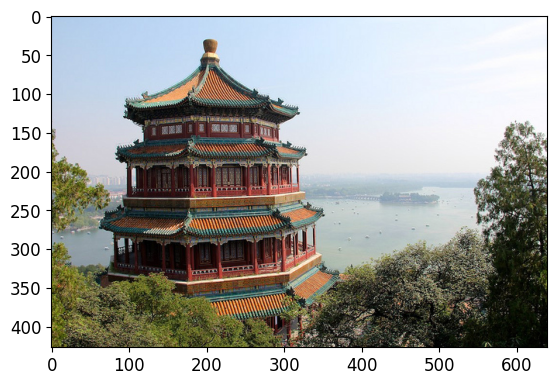

In [30]:
## Visualizing the dataset
data = load_sample_images()["images"]
plt.imshow(data[0])

In [31]:
## np.stack() convert data from python list to numpy to use methods like .shape
## it also create a batch of 2 images so the shape will be (batch, W, H, Channel)
data = np.stack(data)
data = torch.from_numpy(data).type(torch.float)/ 255.0

data.shape


torch.Size([2, 427, 640, 3])

- Let's permute the dimensions from `[batch, height, width, channels]` to `[batch, channels, height, width]`, as PyTorch expects that

In [32]:

data = data.permute(0, 3, 1, 2)
data.shape
    

torch.Size([2, 3, 427, 640])

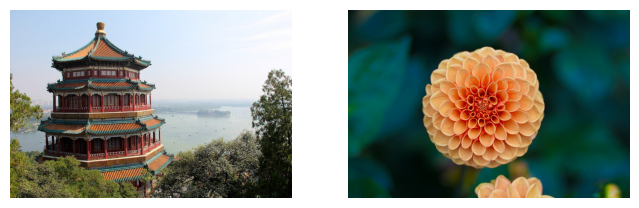

In [33]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, img in enumerate(data):
    plt.subplot(1, 2, index+1)
    plot_image(img)

In [ ]:
import torchvision
import torchvision.transforms.v2 as T 
from torchvision.transforms import v2